<a href="https://colab.research.google.com/github/Yatha04/ML-tinkering/blob/main/BasicClassificationModels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ucimlrepo -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697)

# data (as pandas dataframes)
X = predict_students_dropout_and_academic_success.data.features
y = predict_students_dropout_and_academic_success.data.targets

# metadata
print(predict_students_dropout_and_academic_success.metadata)

# variable information
print(predict_students_dropout_and_academic_success.variables)


{'uci_id': 697, 'name': "Predict Students' Dropout and Academic Success", 'repository_url': 'https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success', 'data_url': 'https://archive.ics.uci.edu/static/public/697/data.csv', 'abstract': "A dataset created from a higher education institution (acquired from several disjoint databases) related to students enrolled in different undergraduate degrees, such as agronomy, design, education, nursing, journalism, management, social service, and technologies.\nThe dataset includes information known at the time of student enrollment (academic path, demographics, and social-economic factors) and the students' academic performance at the end of the first and second semesters. \nThe data is used to build classification models to predict students' dropout and academic sucess. The problem is formulated as a three category classification task, in which there is a strong imbalance towards one of the classes.", 'area': 'Social Sc

In [5]:
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nFirst 5 rows of X:")
print(X.head())
print("\nColumn names:")
print(X.columns.tolist())

Feature matrix shape: (4424, 36)
Target shape: (4424, 1)

First 5 rows of X:
   Marital Status  Application mode  Application order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime/evening attendance  Previous qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           0                       1   

   Previous qualification (grade)  Nacionality  Mother's qualification  \
0                           122.0            1                      19   
1                           160.0  

In [7]:
print("Target column name:", y.columns.tolist())
print("\nClass distribution:")
print(y.value_counts())
print("\nIn percentages:")
print(y.value_counts(normalize=True).round(3) * 100)

Target column name: ['Target']

Class distribution:
Target  
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In percentages:
Target  
Graduate    49.9
Dropout     32.1
Enrolled    17.9
Name: proportion, dtype: float64


In [9]:
print("\nMissing values per column:")
print(X.isnull().sum().sum(), "total missing values")

print("\nFeature value ranges (first look):")
print(X.describe().T[['min', 'max', 'mean', 'std']].head(10))


Missing values per column:
0 total missing values

Feature value ranges (first look):
                                 min     max         mean          std
Marital Status                   1.0     6.0     1.178571     0.605747
Application mode                 1.0    57.0    18.669078    17.484682
Application order                0.0     9.0     1.727848     1.313793
Course                          33.0  9991.0  8856.642631  2063.566416
Daytime/evening attendance       0.0     1.0     0.890823     0.311897
Previous qualification           1.0    43.0     4.577758    10.216592
Previous qualification (grade)  95.0   190.0   132.613314    13.188332
Nacionality                      1.0   109.0     1.873192     6.914514
Mother's qualification           1.0    44.0    19.561935    15.603186
Father's qualification           1.0    44.0    22.275316    15.343108


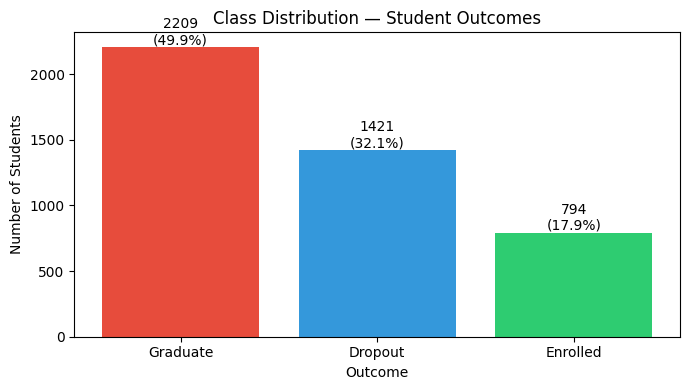

In [11]:
import matplotlib.pyplot as plt

counts = y['Target'].value_counts() # Modified to specify the 'Target' column
plt.figure(figsize=(7, 4))
plt.bar(counts.index, counts.values, color=['#E74C3C','#3498DB','#2ECC71'])
plt.title("Class Distribution — Student Outcomes")
plt.ylabel("Number of Students")
plt.xlabel("Outcome")
for i, (label, val) in enumerate(counts.items()):
    plt.text(i, val + 20, f"{val}\n({val/len(y)*100:.1f}%)", ha='center')
plt.tight_layout()
plt.show()

In [13]:
df = X.copy()
df['Target'] = y['Target'].values

print("Dropout rate by Marital Status:")
print(
    df.groupby('Marital Status')['Target'].apply(lambda x: (x == 'Dropout').mean()).round(3).sort_values(ascending= False)
)

Dropout rate by Marital Status:
Marital Status
6    0.667
2    0.472
4    0.462
5    0.440
1    0.302
3    0.250
Name: Target, dtype: float64


In [14]:
# Coefficient of variation = std/mean, tells you relative spread
cv = (X.std() / X.mean()).abs().sort_values(ascending=False)
print("Top 10 most variable features (relative):")
print(cv.head(10).round(3))
print("\nBottom 10 least variable features:")
print(cv.tail(10).round(3))

Top 10 most variable features (relative):
GDP                                               1152.950
Educational special needs                            9.261
International                                        6.263
Curricular units 1st sem (without evaluations)       5.019
Curricular units 2nd sem (without evaluations)       5.015
Nacionality                                          3.691
Curricular units 2nd sem (credited)                  3.541
Curricular units 1st sem (credited)                  3.325
Debtor                                               2.792
Mother's occupation                                  2.410
dtype: float64

Bottom 10 least variable features:
Curricular units 1st sem (grade)       0.455
Curricular units 1st sem (enrolled)    0.396
Tuition fees up to date                0.368
Curricular units 2nd sem (enrolled)    0.352
Daytime/evening attendance             0.350
Age at enrollment                      0.326
Course                                 0.233
Un

In [15]:
summary = pd.DataFrame({
    'min':  X.min(),
    'max':  X.max(),
    'mean': X.mean().round(2),
    'std':  X.std().round(2),
    'range': (X.max() - X.min()).round(2)
}).sort_values('range', ascending=False)

print(summary.to_string())

                                                  min          max     mean      std    range
Course                                          33.00  9991.000000  8856.64  2063.57  9958.00
Father's occupation                              0.00   195.000000    11.03    25.26   195.00
Mother's occupation                              0.00   194.000000    10.96    26.42   194.00
Nacionality                                      1.00   109.000000     1.87     6.91   108.00
Admission grade                                 95.00   190.000000   126.98    14.48    95.00
Previous qualification (grade)                  95.00   190.000000   132.61    13.19    95.00
Application mode                                 1.00    57.000000    18.67    17.48    56.00
Age at enrollment                               17.00    70.000000    23.27     7.59    53.00
Curricular units 1st sem (evaluations)           0.00    45.000000     8.30     4.18    45.00
Father's qualification                           1.00    44.

In [16]:
import numpy as np

# Convert to binary: Dropout = 1, Graduate/Enrolled = 0
y_binary = (y['Target'] == 'Dropout').astype(int).values

print("Class distribution after encoding:")
print(f"  Dropout     (1): {y_binary.sum()}  ({y_binary.mean()*100:.1f}%)")
print(f"  Not Dropout (0): {(1-y_binary).sum()}  ({(1-y_binary).mean()*100:.1f}%)")

Class distribution after encoding:
  Dropout     (1): 1421  (32.1%)
  Not Dropout (0): 3003  (67.9%)


In [17]:
X_np = X.values.astype(float)

print("X shape:", X_np.shape)
print("y shape:", y_binary.shape)
print("Any NaNs?", np.isnan(X_np).any())

X shape: (4424, 36)
y shape: (4424,)
Any NaNs? False


In [18]:
np.random.seed(42)
n = len(y_binary)
indices = np.random.permutation(n)

split = int(0.8 * n)
train_idx = indices[:split]
test_idx = indices[split:]

X_train, X_test = X_np[train_idx], X_np[test_idx]
y_train = y_binary[train_idx]
y_test = y_binary[test_idx]

print("Train/test split:", len(y_train), len(y_test))

Train/test split: 3539 885


In [19]:
print(f"Training:  {X_train.shape[0]} samples")
print(f"Test:      {X_test.shape[0]} samples")
print(f"Dropout % in train: {y_train.mean()*100:.1f}%")
print(f"Dropout % in test:  {y_test.mean()*100:.1f}%")

Training:  3539 samples
Test:      885 samples
Dropout % in train: 32.5%
Dropout % in test:  30.6%


In [25]:
mean = X_train.mean(axis = 0)
std = X_train.std(axis = 0)

X_train_s = (X_train - mean) / std
X_test_s = (X_test - mean) / std
#print
print("After std normalization:")
print(f"  mean of means: {X_train_s.mean(axis=0).mean():.6f}")
print(f"  std of means:  {X_train_s.std(axis=0).mean():.6f}")

After std normalization:
  mean of means: 0.000000
  std of means:  1.000000


In [26]:
#Perceptron algorithm

In [27]:
class Perceptron:
  def __init__(self, learning_rate=0.01, n_iters=100):
    self.lr = learning_rate
    self.n_iters = n_iters
    self.weights = None
    self.bias = 0
    self.errors = []

  def fit(self, X, y):
    n_samples, n_features = X.shape
    self.weights = np.zeros(n_features)
    self.bias = 0

    for epoch in range(self.n_iters):
      epoch_errors = 0
      for i in range(n_samples):
        x_i = X[i]
        y_i = y[i]

        #Step 1: compute raw score:
        linear = np.dot(x_i, self.weights) + self.bias

        #step 2: Apply step function:
        pred = 1 if linear >= 0 else 0

        #Step 3: Update weight only if wrong

        error = y_i - pred
        if error != 0:
          self.weights += self.lr * error * x_i
          self.bias += self.lr * error
          epoch_errors += 1
      self.errors.append(epoch_errors)
    return self

  def predict(self, X):
    linear = np.dot(X, self.weights) + self.bias
    return np.where(linear >= 0, 1, 0)


In [30]:
p = Perceptron(learning_rate = 0.01, n_iters = 1000)
p.fit(X_train_s, y_train)

print("Training complete.")
print(f"Errors in epoch 1:   {p.errors[0]}")
print(f"Errors in epoch 50:  {p.errors[49]}")
print(f"Errors in last epoch: {p.errors[-1]}")

Training complete.
Errors in epoch 1:   709
Errors in epoch 50:  674
Errors in last epoch: 665


In [31]:
preds = p.predict(X_test_s)

accuracy = np.mean(preds == y_test)
tp = np.sum((preds == 1) & (y_test == 1))
fp = np.sum((preds == 1) & (y_test == 0))
fn = np.sum((preds == 0) & (y_test == 1))
tn = np.sum((preds == 0) & (y_test == 0))

precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"Accuracy:  {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"F1:        {f1*100:.2f}%")
print(f"\nConfusion matrix:")
print(f"  TP={tp}  FP={fp}")
print(f"  FN={fn}  TN={tn}")

Accuracy:  85.88%
Precision: 80.42%
Recall:    71.22%
F1:        75.54%

Confusion matrix:
  TP=193  FP=47
  FN=78  TN=567


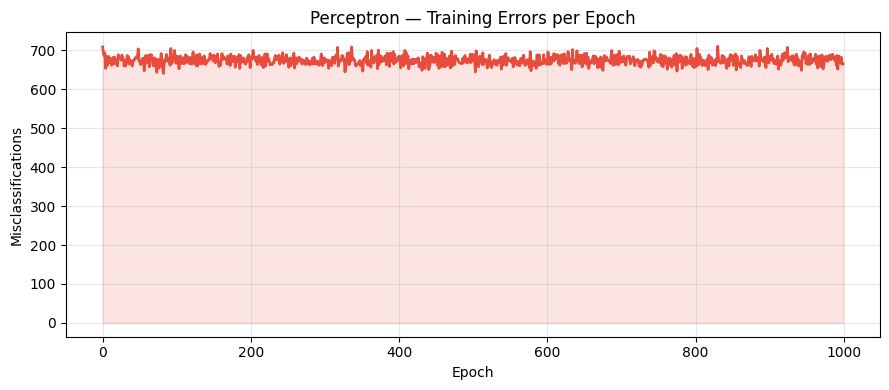

In [32]:
plt.figure(figsize=(9, 4))
plt.plot(p.errors, color='#E74C3C', linewidth=2)
plt.fill_between(range(len(p.errors)), p.errors, alpha=0.15, color='#E74C3C')
plt.xlabel("Epoch")
plt.ylabel("Misclassifications")
plt.title("Perceptron — Training Errors per Epoch")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Hyperparameter Tuning: Learning Rate

Let's evaluate the Perceptron model with different learning rates to see how it impacts the accuracy.

In [33]:
learning_rates = [0.001, 0.01, 0.1, 1.0]

for lr in learning_rates:
    print(f"\n--- Training Perceptron with learning rate: {lr} ---")

    # Instantiate and fit the Perceptron model
    perceptron_tuned = Perceptron(learning_rate=lr, n_iters=1000) # Re-using n_iters from previous training
    perceptron_tuned.fit(X_train_s, y_train)

    # Make predictions on the test set
    predictions_tuned = perceptron_tuned.predict(X_test_s)

    # Calculate accuracy
    accuracy_tuned = np.mean(predictions_tuned == y_test)
    print(f"Accuracy on test set: {accuracy_tuned*100:.2f}%")

    # Optionally, you could print other metrics or plot errors for each LR
    # print(f"Errors in last epoch: {perceptron_tuned.errors[-1]}")


--- Training Perceptron with learning rate: 0.001 ---
Accuracy on test set: 85.88%

--- Training Perceptron with learning rate: 0.01 ---
Accuracy on test set: 85.88%

--- Training Perceptron with learning rate: 0.1 ---
Accuracy on test set: 85.88%

--- Training Perceptron with learning rate: 1.0 ---
Accuracy on test set: 85.88%


In [35]:
class KNN:
  def __init__(self, k = 5):
    self.k = k
    self.X_train = None
    self.y_train = None

  def fit(self, X, y):
    self.X_train = X
    self.y_train = y
    return self

  def predict(self, X):
    predictions = []
    for x in X:

      #Step 1: compute squared distances to every training point
      dists = np.sum((self.X_train - x)**2, axis = 1)

      #Step 2: get k nearest indices
      k_indices = np.argsort(dists)[:self.k]

      #Step 3: majority vote among k neighbors
      k_labels = self.y_train[k_indices]
      votes = np.bincount(k_labels)
      predictions.append(np.argmax(votes))

    return np.array(predictions)


In [36]:
k_values = range(1,31)
results = []

for k in k_values:
  model = KNN(k = k)
  model.fit(X_train_s, y_train)
  preds = model.predict(X_test_s)
  accuracy = np.mean(preds == y_test)

  acc = np.mean(preds == y_test)
  tp  = np.sum((preds == 1) & (y_test == 1))
  fn  = np.sum((preds == 0) & (y_test == 1))
  fp  = np.sum((preds == 1) & (y_test == 0))
  rec = tp / (tp + fn) if (tp + fn) > 0 else 0

  results.append((k, acc, rec))
  print(f"k={k:<3}  acc={acc*100:.2f}%  recall={rec*100:.2f}%")

k=1    acc=81.47%  recall=66.42%
k=2    acc=82.71%  recall=51.29%
k=3    acc=83.50%  recall=62.73%
k=4    acc=83.62%  recall=53.51%
k=5    acc=85.08%  recall=61.99%
k=6    acc=83.95%  recall=53.87%
k=7    acc=84.18%  recall=57.20%
k=8    acc=83.62%  recall=52.77%
k=9    acc=83.62%  recall=55.35%
k=10   acc=83.84%  recall=52.77%
k=11   acc=83.95%  recall=55.72%
k=12   acc=83.95%  recall=53.14%
k=13   acc=84.07%  recall=55.72%
k=14   acc=84.07%  recall=54.24%
k=15   acc=84.52%  recall=56.83%
k=16   acc=84.29%  recall=53.51%
k=17   acc=84.41%  recall=55.72%
k=18   acc=83.84%  recall=52.77%
k=19   acc=84.63%  recall=55.72%
k=20   acc=84.52%  recall=53.87%
k=21   acc=84.41%  recall=54.24%
k=22   acc=84.52%  recall=53.87%
k=23   acc=84.52%  recall=54.98%
k=24   acc=84.18%  recall=53.51%
k=25   acc=84.18%  recall=54.61%
k=26   acc=83.84%  recall=52.77%
k=27   acc=84.29%  recall=54.98%
k=28   acc=84.29%  recall=54.24%
k=29   acc=84.52%  recall=54.98%
k=30   acc=84.07%  recall=53.14%


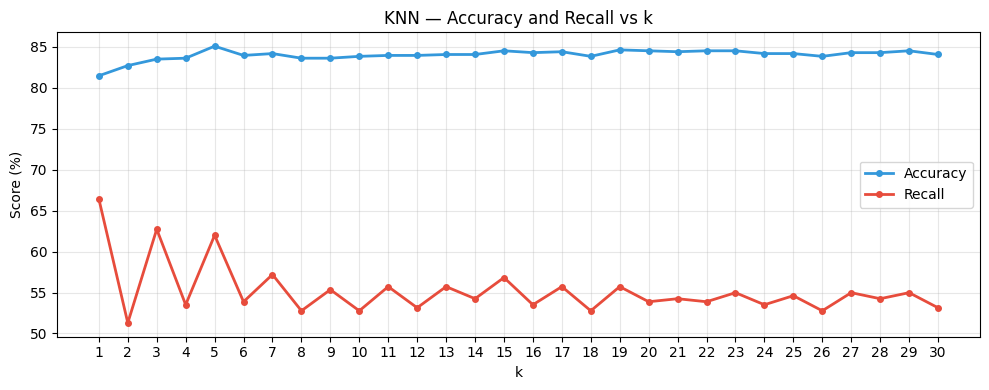

In [37]:
ks   = [r[0] for r in results]
accs = [r[1]*100 for r in results]
recs = [r[2]*100 for r in results]

plt.figure(figsize=(10, 4))
plt.plot(ks, accs, label='Accuracy', color='#3498DB', linewidth=2, marker='o', ms=4)
plt.plot(ks, recs, label='Recall',   color='#E74C3C', linewidth=2, marker='o', ms=4)
plt.xlabel("k")
plt.ylabel("Score (%)")
plt.title("KNN — Accuracy and Recall vs k")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(ks)
plt.tight_layout()
plt.show()

In [38]:
best_k = 1   # based on recall
knn = KNN(k=best_k)
knn.fit(X_train_s, y_train)
preds_knn = knn.predict(X_test_s)

tp = np.sum((preds_knn == 1) & (y_test == 1))
fp = np.sum((preds_knn == 1) & (y_test == 0))
fn = np.sum((preds_knn == 0) & (y_test == 1))
tn = np.sum((preds_knn == 0) & (y_test == 0))

precision = tp / (tp + fp)
recall    = tp / (tp + fn)
f1        = 2*precision*recall / (precision + recall)

print(f"KNN (k={best_k}) Results:")
print(f"  Accuracy:  {np.mean(preds_knn == y_test)*100:.2f}%")
print(f"  Precision: {precision*100:.2f}%")
print(f"  Recall:    {recall*100:.2f}%")
print(f"  F1:        {f1*100:.2f}%")
print(f"\n  TP={tp}  FP={fp}")
print(f"  FN={fn}  TN={tn}")

KNN (k=1) Results:
  Accuracy:  81.47%
  Precision: 71.15%
  Recall:    66.42%
  F1:        68.70%

  TP=180  FP=73
  FN=91  TN=541


In [39]:
#Principal Component Analysis:
##Breaking down the 36 features into smaller dimensions using PCA

class PCA:
  def __init__(self, n_components):
    self.n_components = n_components
    self.components = None
    self.mean = None
    self.explained_variance_ratio = None

  def fit(self, X):
    #Step 1: Center
    self.mean = X.mean(axis = 0)
    X_c = X - self.mean

    #Step 2: Covariance matrix

    C = (X_c.T @ X_c) / (len(X) - 1)

    #Step 3: Eigendecomposition
    #eigh is for symmetric matrices - more stable than eig
    eigenvalues, eigenvectors = np.linalg.eigh(C)

    #Step 4: sort descending
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    #Step 5: keep top k
    self.components = eigenvectors[:, :self.n_components].T
    self.explained_variance_ratio = eigenvalues[:self.n_components] / eigenvalues.sum()

    return self

  def transform(self, X):
    X_c = X - self.mean
    return X_c @ self.components.T

  def fit_transform(self, X):
    return self.fit(X).transform(X)



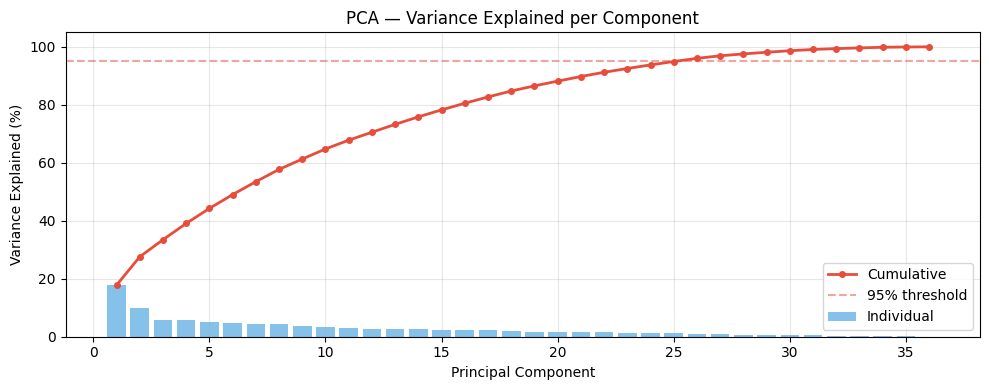

Components to explain 95% variance: 26
Top 2 components explain: 27.6%
Top 5 components explain: 44.3%
Top 10 components explain: 64.8%


In [40]:
pca_full = PCA(n_components=36)
pca_full.fit(X_train_s)

cumulative = np.cumsum(pca_full.explained_variance_ratio)

plt.figure(figsize=(10, 4))
plt.bar(range(1, 37), pca_full.explained_variance_ratio * 100,
        alpha=0.6, color='#3498DB', label='Individual')
plt.plot(range(1, 37), cumulative * 100,
         color='#E74C3C', linewidth=2, marker='o', ms=4, label='Cumulative')
plt.axhline(95, color='#E74C3C', linestyle='--', alpha=0.5, label='95% threshold')
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.title("PCA — Variance Explained per Component")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find how many components hit 95%
n_95 = np.searchsorted(cumulative, 0.95) + 1
print(f"Components to explain 95% variance: {n_95}")
print(f"Top 2 components explain: {cumulative[1]*100:.1f}%")
print(f"Top 5 components explain: {cumulative[4]*100:.1f}%")
print(f"Top 10 components explain: {cumulative[9]*100:.1f}%")

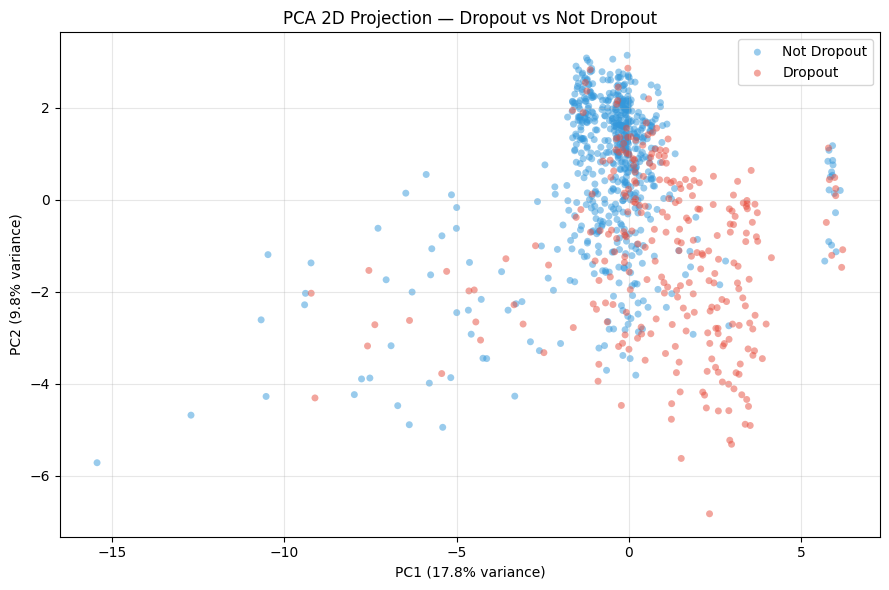

In [45]:
pca_2d = PCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train_s)
X_test_2d  = pca_2d.transform(X_test_s)

plt.figure(figsize=(9, 6))
for label, color, name in zip([0, 1], ['#3498DB', '#E74C3C'], ['Not Dropout', 'Dropout']):
    mask = y_test == label
    plt.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
                c=color, label=name, alpha=0.5, s=25, edgecolors='none')

plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio[1]*100:.1f}% variance)")
plt.title("PCA 2D Projection — Dropout vs Not Dropout")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
dims = [2, 5, 10, 15, 20, 26, 36]
print(f"{'Dimensions':<14} {'Var Explained':>14} {'Accuracy':>10} {'Recall':>9} {'F1':>8}")
print("-" * 58)

for d in dims:
    if d == 36:
        # Original data, no PCA
        Xtr, Xte = X_train_s, X_test_s
        var = 1.0
    else:
        pca = PCA(n_components=d)
        Xtr = pca.fit_transform(X_train_s)
        Xte = pca.transform(X_test_s)
        var = np.sum(pca.explained_variance_ratio)

    model = KNN(k=1)
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)

    acc = np.mean(preds == y_test)
    tp  = np.sum((preds == 1) & (y_test == 1))
    fn  = np.sum((preds == 0) & (y_test == 1))
    fp  = np.sum((preds == 1) & (y_test == 0))
    rec = tp / (tp + fn)
    f1  = 2*(tp/(tp+fp))*rec / ((tp/(tp+fp)) + rec)

    label = "original" if d == 36 else f"{d} components"
    print(f"{label:<14}  {var*100:>12.1f}%  {acc*100:>9.2f}%  {rec*100:>8.2f}%  {f1*100:>7.2f}%")

Dimensions      Var Explained   Accuracy    Recall       F1
----------------------------------------------------------
2 components            27.6%      76.84%     63.10%    62.52%
5 components            44.3%      79.32%     66.42%    66.30%
10 components           64.8%      81.13%     69.74%    69.36%
15 components           78.3%      80.23%     64.21%    66.54%
20 components           88.2%      80.68%     66.79%    67.92%
26 components           96.0%      80.68%     67.16%    68.04%
original               100.0%      81.47%     66.42%    68.70%


In [46]:
class SVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = learning_rate
        self.lam = lambda_param      # regularization: higher = wider margin, less fit
        self.n_iters = n_iters
        self.weights = None
        self.bias = 0
        self.losses = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        # SVM needs labels in {-1, +1} not {0, 1}
        y_ = np.where(y > 0, 1.0, -1.0)

        self.weights = np.zeros(n_features)
        self.bias = 0

        for epoch in range(self.n_iters):
            # Shuffle each epoch
            idx = np.random.permutation(n_samples)

            for i in idx:
                x_i, yi = X[i], y_[i]
                margin = yi * (np.dot(x_i, self.weights) + self.bias)

                if margin >= 1:
                    # Outside margin — only apply regularization
                    self.weights -= self.lr * self.lam * self.weights
                else:
                    # Inside margin or wrong — full update
                    self.weights -= self.lr * (self.lam * self.weights - yi * x_i)
                    self.bias    += self.lr * yi

            # Track loss each epoch
            margins_all = y_ * (X @ self.weights + self.bias)
            hinge = np.maximum(0, 1 - margins_all).mean()
            reg   = (self.lam / 2) * np.dot(self.weights, self.weights)
            self.losses.append(hinge + reg)

        return self

    def predict(self, X):
        raw = np.dot(X, self.weights) + self.bias
        return np.where(raw >= 0, 1, 0)

SVM Results:
  Accuracy:  86.55%
  Precision: 88.38%
  Recall:    64.58%
  F1:        74.63%

  TP=175  FP=23
  FN=96  TN=591


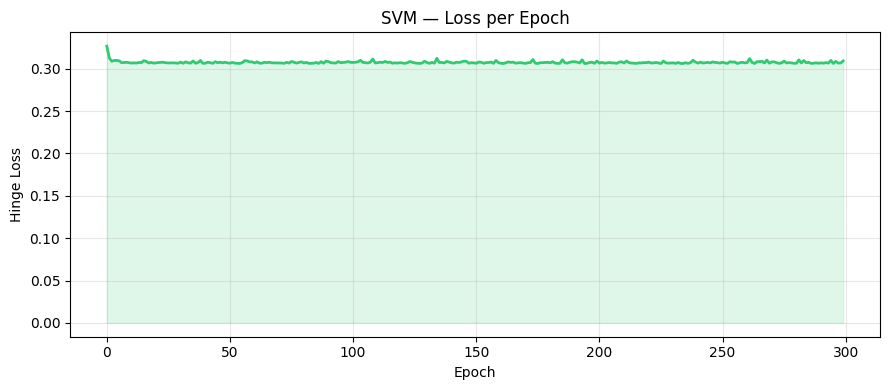

In [48]:
np.random.seed(42)
svm = SVM(learning_rate=0.001, lambda_param=0.01, n_iters=300)
svm.fit(X_train_s, y_train)
preds_svm = svm.predict(X_test_s)

tp = np.sum((preds_svm == 1) & (y_test == 1))
fp = np.sum((preds_svm == 1) & (y_test == 0))
fn = np.sum((preds_svm == 0) & (y_test == 1))
tn = np.sum((preds_svm == 0) & (y_test == 0))

precision = tp / (tp + fp)
recall    = tp / (tp + fn)
f1        = 2*precision*recall / (precision + recall)

print(f"SVM Results:")
print(f"  Accuracy:  {np.mean(preds_svm == y_test)*100:.2f}%")
print(f"  Precision: {precision*100:.2f}%")
print(f"  Recall:    {recall*100:.2f}%")
print(f"  F1:        {f1*100:.2f}%")
print(f"\n  TP={tp}  FP={fp}")
print(f"  FN={fn}  TN={tn}")

# Loss curve
plt.figure(figsize=(9, 4))
plt.plot(svm.losses, color='#2ECC71', linewidth=2)
plt.fill_between(range(len(svm.losses)), svm.losses, alpha=0.15, color='#2ECC71')
plt.xlabel("Epoch")
plt.ylabel("Hinge Loss")
plt.title("SVM — Loss per Epoch")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [50]:
print(f"{'Lambda':<10} {'Accuracy':>10} {'Precision':>11} {'Recall':>8} {'F1':>8} {'FP':>6} {'FN':>6}")
print("-" * 62)

for lam in [0.001, 0.005, 0.01, 0.05, 0.1]:
    np.random.seed(42)
    m = SVM(learning_rate=0.001, lambda_param=lam, n_iters=300)
    m.fit(X_train_s, y_train)
    p = m.predict(X_test_s)

    tp = np.sum((p == 1) & (y_test == 1))
    fp = np.sum((p == 1) & (y_test == 0))
    fn = np.sum((p == 0) & (y_test == 1))
    acc  = np.mean(p == y_test)
    prec = tp / (tp + fp)
    rec  = tp / (tp + fn)
    f1   = 2*prec*rec / (prec + rec)

    print(f"{lam:<10} {acc*100:>9.2f}% {prec*100:>10.2f}% {rec*100:>7.2f}% {f1*100:>7.2f}% {fp:>6} {fn:>6}")

Lambda       Accuracy   Precision   Recall       F1     FP     FN
--------------------------------------------------------------


KeyboardInterrupt: 

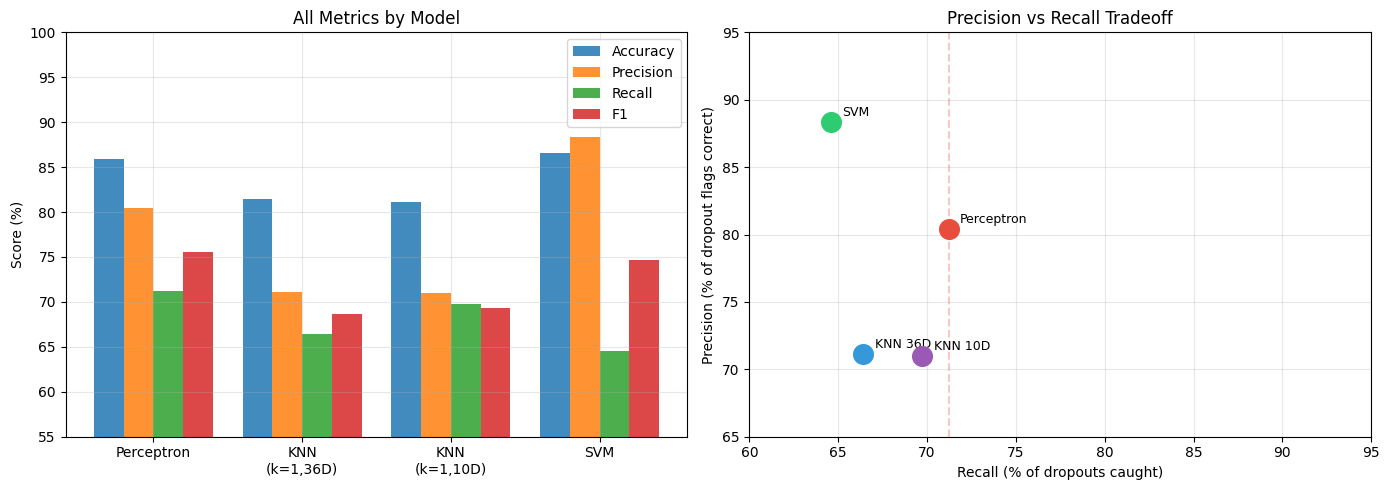

In [51]:
models  = ['Perceptron', 'KNN\n(k=1,36D)', 'KNN\n(k=1,10D)', 'SVM']
metrics = {
    'Accuracy':  [85.88, 81.47, 81.13, 86.55],
    'Precision': [80.42, 71.15, 71.00, 88.38],
    'Recall':    [71.22, 66.42, 69.74, 64.58],
    'F1':        [75.54, 68.70, 69.36, 74.63],
}
colors = ['#E74C3C', '#3498DB', '#9B59B6', '#2ECC71']

x = np.arange(len(models))
width = 0.2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all metrics grouped by model
ax = axes[0]
for i, (metric, vals) in enumerate(metrics.items()):
    ax.bar(x + i*width, vals, width, label=metric, alpha=0.85)
ax.set_xticks(x + width*1.5)
ax.set_xticklabels(models)
ax.set_ylabel("Score (%)")
ax.set_ylim(55, 100)
ax.set_title("All Metrics by Model")
ax.legend()
ax.grid(True, alpha=0.3)

# Right: precision vs recall tradeoff
ax = axes[1]
precs   = [80.42, 71.15, 71.00, 88.38]
recalls = [71.22, 66.42, 69.74, 64.58]
names   = ['Perceptron', 'KNN 36D', 'KNN 10D', 'SVM']

for name, prec, rec, col in zip(names, precs, recalls, colors):
    ax.scatter(rec, prec, s=200, color=col, zorder=5, label=name)
    ax.annotate(name, (rec, prec), textcoords="offset points",
                xytext=(8, 4), fontsize=9)

ax.set_xlabel("Recall (% of dropouts caught)")
ax.set_ylabel("Precision (% of dropout flags correct)")
ax.set_title("Precision vs Recall Tradeoff")
ax.set_xlim(60, 95)
ax.set_ylim(65, 95)
ax.grid(True, alpha=0.3)
ax.axvline(71.22, color='#E74C3C', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()are we

In [52]:
from sklearn.svm import SVC

# RBF kernel SVM
svm_rbf = SVC(kernel='rbf', C=1.0, random_state=42)
svm_rbf.fit(X_train_s, y_train)
preds_rbf = svm_rbf.predict(X_test_s)

tp = np.sum((preds_rbf==1) & (y_test==1))
fp = np.sum((preds_rbf==1) & (y_test==0))
fn = np.sum((preds_rbf==0) & (y_test==1))

print(f"Kernel SVM (RBF) — sklearn reference:")
print(f"  Accuracy:  {np.mean(preds_rbf==y_test)*100:.2f}%")
print(f"  Recall:    {tp/(tp+fn)*100:.2f}%")
print(f"  F1:        {2*tp/(2*tp+fp+fn)*100:.2f}%")
print(f"  Support vectors used: {svm_rbf.n_support_}")

Kernel SVM (RBF) — sklearn reference:
  Accuracy:  87.01%
  Recall:    67.53%
  F1:        76.09%
  Support vectors used: [747 656]
